In [516]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the Excel file
df = pd.read_excel('Gujarat_Tourism_2015-2024_Full.xlsx')

# Check shape and first rows
print("Shape:", df.shape)
df.head()

Shape: (3555, 15)


,Year,Month,Quarter,District,Tourist Place,Category,Domestic Visitors,Foreign Visitors,Total Visitors,Revenue (₹),Average Stay (Days),Hotel Occupancy (%),Season,Rating,Region
0,2015,January,Q1,Ahmedabad,Sabarmati Ashram,Heritage,13874,1670,15544,9917300,1.2,87.5,Winter,4.7,Central Gujarat
1,2015,January,Q1,Ahmedabad,Kankaria Lake,Leisure,12288,376,12664,5629600,1.2,84.9,Winter,4.3,Central Gujarat
2,2015,January,Q1,Gandhinagar,Akshardham Temple,Religious,16379,1045,17424,7613650,1.1,89.2,Winter,4.6,Central Gujarat
3,2015,January,Q1,Vadodara,Laxmi Vilas Palace,Heritage,9700,1288,10988,7198600,1.2,87.1,Winter,4.5,Central Gujarat
4,2015,January,Q1,Vadodara,Champaner-Pavagadh,Heritage,7715,773,8488,5172350,1.5,86.1,Winter,4.3,Central Gujarat


In [517]:
# How many rows and columns?
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

# Column names
print("\nColumn names:")
print(df.columns.tolist())

Rows: 3555
Columns: 15

Column names:
['Year', 'Month', 'Quarter', 'District', 'Tourist Place', 'Category', 'Domestic Visitors', 'Foreign Visitors', 'Total Visitors', 'Revenue (₹)', 'Average Stay (Days)', 'Hotel Occupancy (%)', 'Season', 'Rating', 'Region']


In [518]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load data
df = pd.read_excel('Gujarat_Tourism_2015-2024_Full.xlsx')

# Basic exploration
print(df.shape)
print(df.info())
print(df.head())
print(df.describe())

(3555, 15)
<class 'pandas.DataFrame'>
RangeIndex: 3555 entries, 0 to 3554
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Year                 3555 non-null   int64  
 1   Month                3555 non-null   str    
 2   Quarter              3555 non-null   str    
 3   District             3555 non-null   str    
 4   Tourist Place        3555 non-null   str    
 5   Category             3555 non-null   str    
 6   Domestic Visitors    3555 non-null   int64  
 7   Foreign Visitors     3555 non-null   int64  
 8   Total Visitors       3555 non-null   int64  
 9   Revenue (₹)          3555 non-null   int64  
 10  Average Stay (Days)  3555 non-null   float64
 11  Hotel Occupancy (%)  3555 non-null   float64
 12  Season               3555 non-null   str    
 13  Rating               3555 non-null   float64
 14  Region               3555 non-null   str    
dtypes: float64(3), int64(5), str(7)
memory

In [519]:
# Check for duplicate rows
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [520]:
total_visitors = df['Total Visitors'].sum()
total_revenue = df['Revenue (₹)'].sum()
avg_occupancy = df['Hotel Occupancy (%)'].mean()
avg_rating = df['Rating'].mean()

print(f"Total Visitors: {total_visitors:,.0f}")
print(f"Total Revenue: ₹{total_revenue:,.0f}")
print(f"Average Hotel Occupancy: {avg_occupancy:.2f}%")
print(f"Average Rating: {avg_rating:.2f}")

Total Visitors: 30,712,560
Total Revenue: ₹23,509,399,727
Average Hotel Occupancy: 72.51%
Average Rating: 4.23


In [521]:
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

df['Month'] = pd.Categorical(df['Month'], categories=month_order, ordered=True)

print("Month order set successfully!")

Month order set successfully!


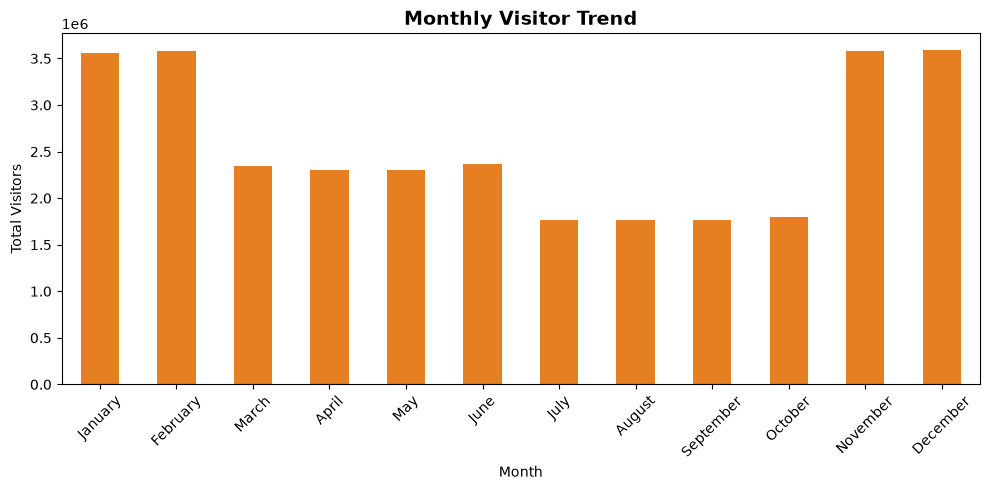

In [522]:
monthly_data = df.groupby('Month', observed=True)['Total Visitors'].sum()

plt.figure(figsize=(10,5))
monthly_data.plot(kind='bar', color='#E67E22')
plt.title('Monthly Visitor Trend', fontsize=14, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Total Visitors')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

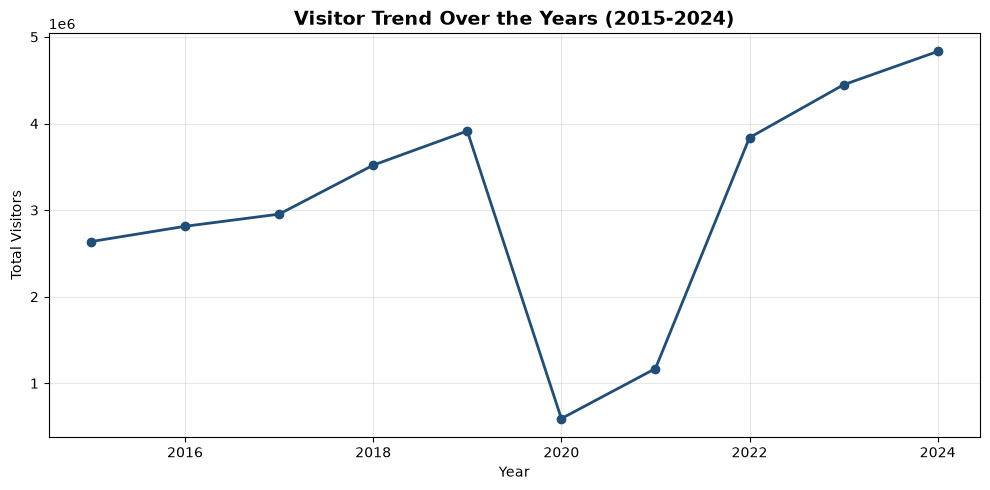

In [523]:
yearly_data = df.groupby('Year')['Total Visitors'].sum()

plt.figure(figsize=(10,5))
yearly_data.plot(kind='line', marker='o', color='#1F4E79', linewidth=2)
plt.title('Visitor Trend Over the Years (2015-2024)', fontsize=14, fontweight='bold')
plt.xlabel('Year')
plt.ylabel('Total Visitors')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

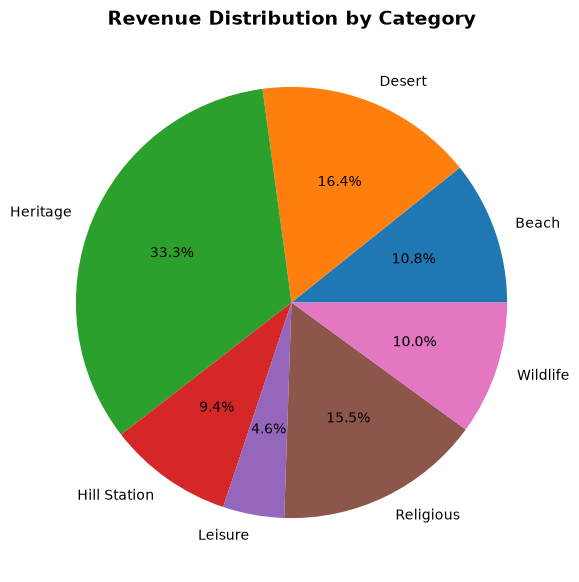

In [524]:
category_data = df.groupby('Category')['Revenue (₹)'].sum()

plt.figure(figsize=(7,7))
plt.pie(category_data, labels=category_data.index, autopct='%1.1f%%')
plt.title('Revenue Distribution by Category', fontsize=14, fontweight='bold')
plt.show()

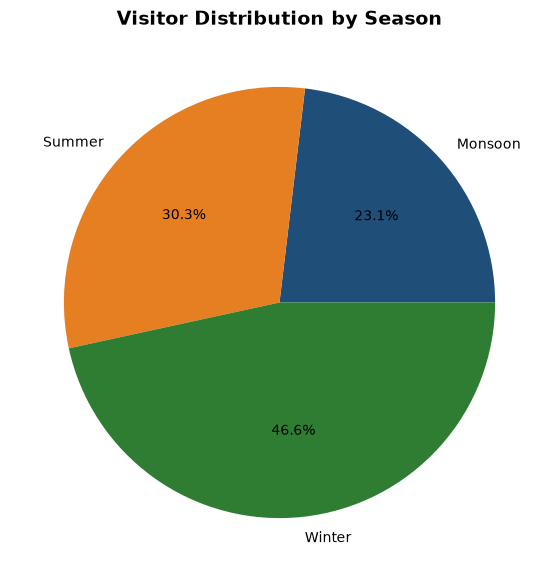

In [525]:
season_data = df.groupby('Season')['Total Visitors'].sum()

plt.figure(figsize=(7,7))
plt.pie(season_data, labels=season_data.index, autopct='%1.1f%%', 
        colors=['#1F4E79','#E67E22','#2E7D32'])
plt.title('Visitor Distribution by Season', fontsize=14, fontweight='bold')
plt.show()

In [526]:
top_places_table = df.groupby(['Tourist Place', 'District']).agg(
    Domestic_Visitors=('Domestic Visitors', 'sum'),
    Foreign_Visitors=('Foreign Visitors', 'sum'),
    Total_Visitors=('Total Visitors', 'sum')
).reset_index().sort_values('Total_Visitors', ascending=False).head(10)

top_places_table

,Tourist Place,District,Domestic_Visitors,Foreign_Visitors,Total_Visitors
24,Rann of Kutch (White Desert),Kutch,2039946,453886,2493832
27,Somnath Temple,Gir Somnath,1849245,76829,1926074
11,Dwarkadhish Temple,Devbhoomi Dwarka,1670295,51847,1722142
1,Akshardham Temple,Gandhinagar,1574394,84200,1658594
25,Sabarmati Ashram,Ahmedabad,1388973,188538,1577511
28,Statue of Unity,Narmada,1315795,133023,1448818
12,Gir National Park,Gir Somnath,1223052,199633,1422685
15,Kankaria Lake,Ahmedabad,1304678,40810,1345488
2,Ambaji Temple,Banaskantha,1275612,25716,1301328
18,Laxmi Vilas Palace,Vadodara,1095149,119511,1214660


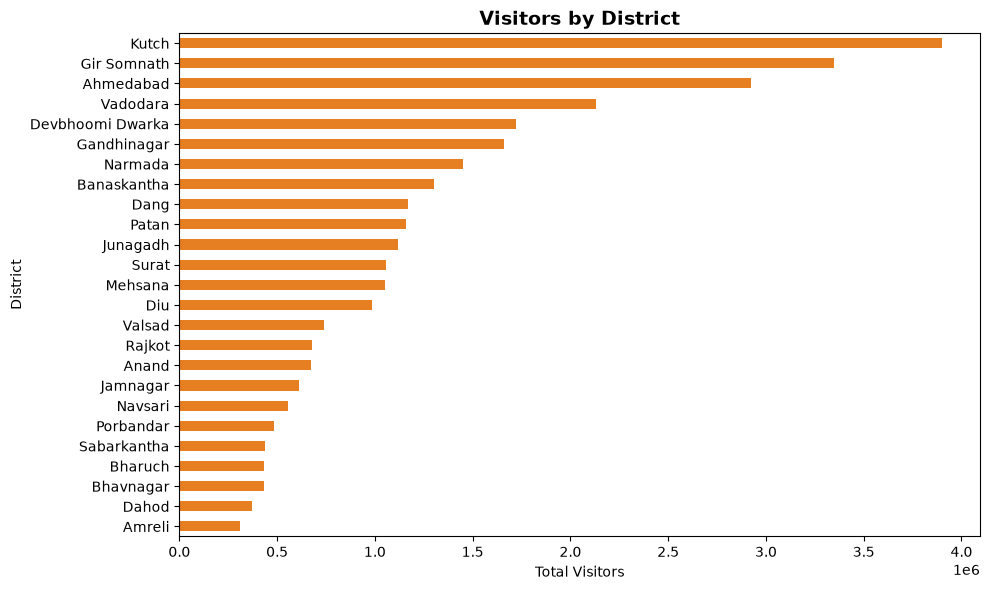

In [527]:
district_data = df.groupby('District')['Total Visitors'].sum().sort_values(ascending=False)

plt.figure(figsize=(10,6))
district_data.plot(kind='barh', color='#E67E22')
plt.title('Visitors by District', fontsize=14, fontweight='bold')
plt.xlabel('Total Visitors')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [528]:
visitors_2019 = df[df['Year']==2019]['Total Visitors'].sum()
visitors_2020 = df[df['Year']==2020]['Total Visitors'].sum()
visitors_2021 = df[df['Year']==2021]['Total Visitors'].sum()
visitors_2022 = df[df['Year']==2022]['Total Visitors'].sum()

# Change % between each consecutive year
change_2019_2020 = ((visitors_2020 - visitors_2019) / visitors_2019) * 100
change_2020_2021 = ((visitors_2021 - visitors_2020) / visitors_2020) * 100
change_2021_2022 = ((visitors_2022 - visitors_2021) / visitors_2021) * 100

print(f"Visitors in 2019: {visitors_2019:,.0f}")
print(f"Visitors in 2020: {visitors_2020:,.0f}")
print(f"Visitors in 2021: {visitors_2021:,.0f}")
print(f"Visitors in 2022: {visitors_2022:,.0f}")
print()
print(f"Change 2019 to 2020: {change_2019_2020:.2f}%")
print(f"Change 2020 to 2021: {change_2020_2021:.2f}%")
print(f"Change 2021 to 2022: {change_2021_2022:.2f}%")

Visitors in 2019: 3,913,686
Visitors in 2020: 591,882
Visitors in 2021: 1,169,495
Visitors in 2022: 3,837,006

Change 2019 to 2020: -84.88%
Change 2020 to 2021: 97.59%
Change 2021 to 2022: 228.09%


In [529]:
df[df['Year'].isin([2020,2021,2022])].groupby('Year')['Total Visitors'].sum()

Year
2020     591882
2021    1169495
2022    3837006
Name: Total Visitors, dtype: int64

In [530]:
yearly_data = df.groupby('Year')['Total Visitors'].sum()
yoy_growth = yearly_data.pct_change() * 100

yoy_table = yoy_growth.reset_index()
yoy_table.columns = ['Year', 'Growth %']

yoy_table

,Year,Growth %
0,2015,NaN
1,2016,6.698445
2,2017,4.989281
3,2018,19.167238
4,2019,11.213139
5,2020,-84.876610
6,2021,97.589215
7,2022,228.090843
8,2023,15.907064
9,2024,8.650951


In [531]:
best_year = yoy_growth.idxmax()
worst_year = yoy_growth.idxmin()

print(f"Best Growth Year: {best_year} ({yoy_growth.max():.2f}%)")
print(f"Worst Growth Year: {worst_year} ({yoy_growth.min():.2f}%)")

Best Growth Year: 2022 (228.09%)
Worst Growth Year: 2020 (-84.88%)


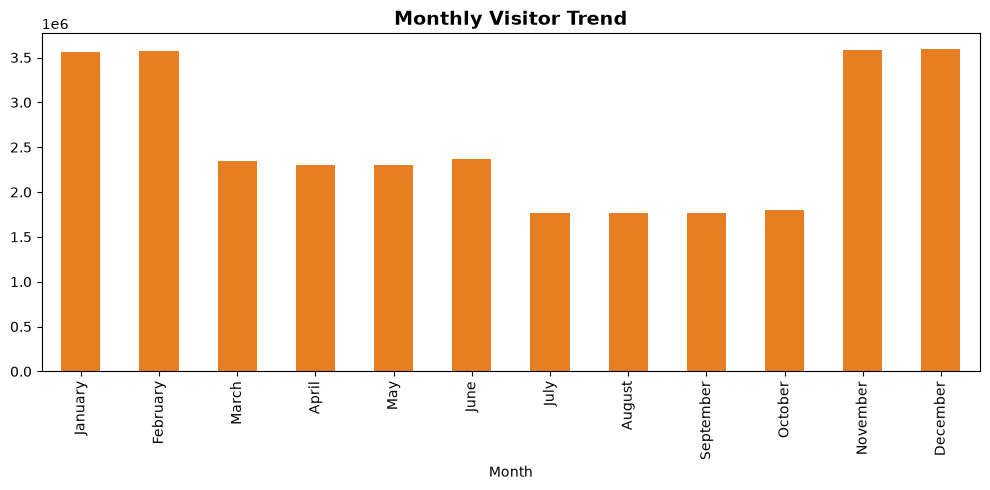

Chart saved to outputs/monthly_trend.png


In [532]:
import os

# Create output folder
os.makedirs('outputs', exist_ok=True)

# Re-plot and save each chart
monthly_data = df.groupby('Month', observed=True)['Total Visitors'].sum()
plt.figure(figsize=(10,5))
monthly_data.plot(kind='bar', color='#E67E22')
plt.title('Monthly Visitor Trend', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('outputs/monthly_trend.png', dpi=150)
plt.show()

print("Chart saved to outputs/monthly_trend.png")

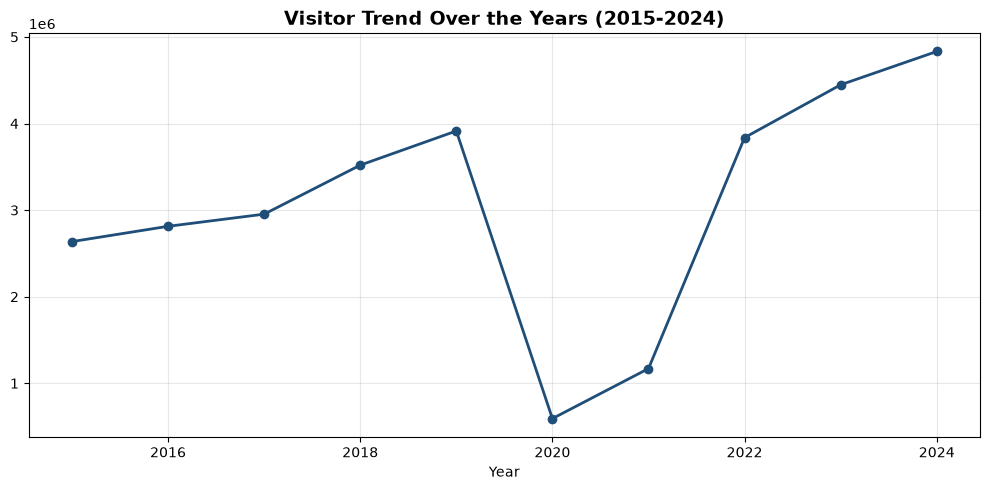

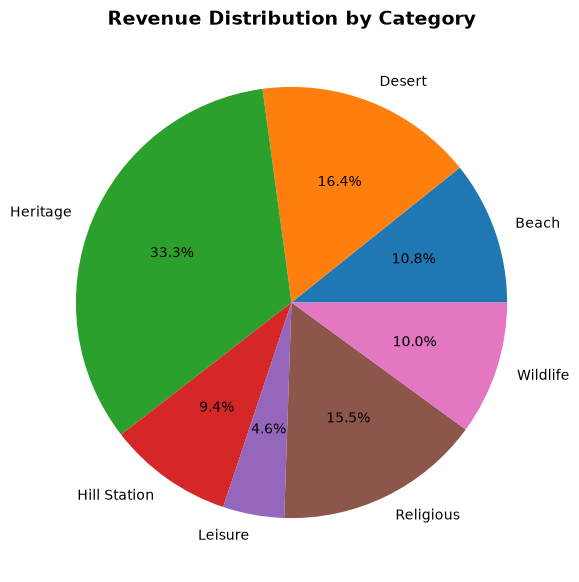

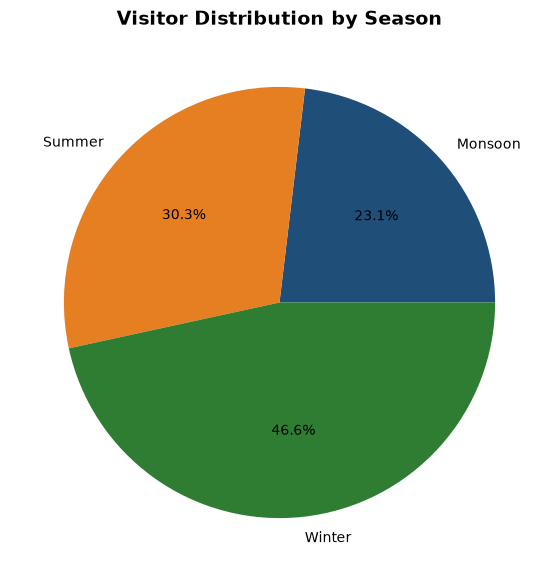

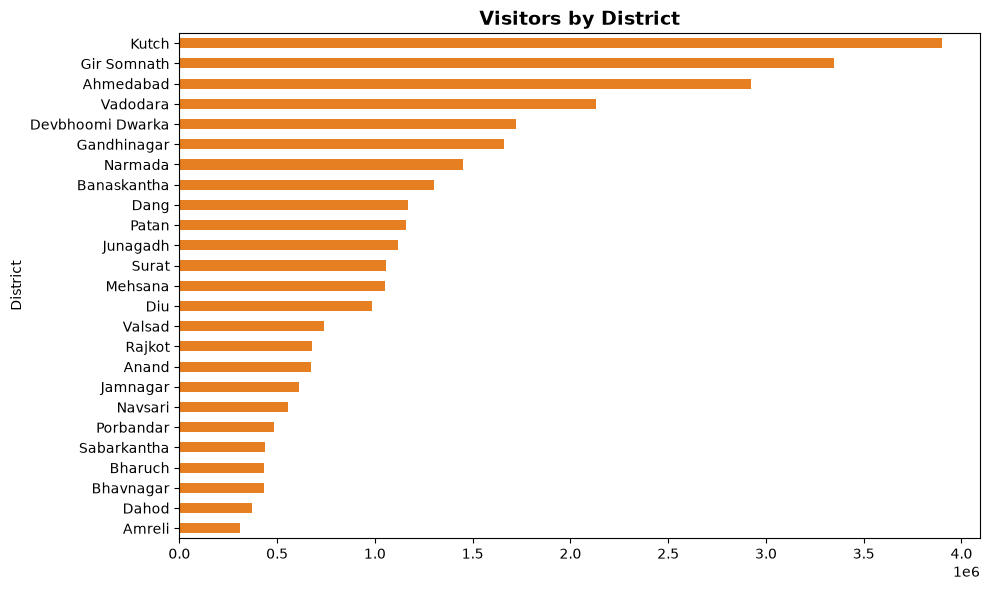

All charts saved in 'outputs' folder!


In [533]:
os.makedirs('outputs', exist_ok=True)

# 1. Yearly trend
yearly_data = df.groupby('Year')['Total Visitors'].sum()
plt.figure(figsize=(10,5))
yearly_data.plot(kind='line', marker='o', color='#1F4E79', linewidth=2)
plt.title('Visitor Trend Over the Years (2015-2024)', fontsize=14, fontweight='bold')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('outputs/yearly_trend.png', dpi=150)
plt.show()

# 2. Revenue by category
category_data = df.groupby('Category')['Revenue (₹)'].sum()
plt.figure(figsize=(7,7))
plt.pie(category_data, labels=category_data.index, autopct='%1.1f%%')
plt.title('Revenue Distribution by Category', fontsize=14, fontweight='bold')
plt.savefig('outputs/revenue_by_category.png', dpi=150)
plt.show()

# 3. Season-wise visitors
season_data = df.groupby('Season')['Total Visitors'].sum()
plt.figure(figsize=(7,7))
plt.pie(season_data, labels=season_data.index, autopct='%1.1f%%', colors=['#1F4E79','#E67E22','#2E7D32'])
plt.title('Visitor Distribution by Season', fontsize=14, fontweight='bold')
plt.savefig('outputs/season_visitors.png', dpi=150)
plt.show()



# 4. District-wise visitors
district_data = df.groupby('District')['Total Visitors'].sum().sort_values(ascending=False)
plt.figure(figsize=(10,6))
district_data.plot(kind='barh', color='#E67E22')
plt.title('Visitors by District', fontsize=14, fontweight='bold')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.savefig('outputs/district_visitors.png', dpi=150)
plt.show()

print("All charts saved in 'outputs' folder!")